# Mid-Stance Pressure Distribution Entropy + FFT Analysis

## Is FFT a Good Fit for This Feature?

**Short answer: Yes — but with important nuance about *where* you apply it.**

The FFT decomposes a signal into its constituent frequencies, revealing periodicity and spectral energy distribution. For gait pressure data, there are **four meaningfully different places** to apply it, each answering a different question:

| FFT Application | Input Signal | What It Reveals | Useful? |
|---|---|---|---|
| **A. Whole-signal FFT** | Total pressure over full recording | Cadence frequency + harmonic structure | ✅ Strong |
| **B. Spectral entropy of PSD** | Power spectrum of whole signal | How 'peaked' vs 'spread' the gait rhythm is | ✅ Meaningful |
| **C. Average stance profile FFT** | Normalised stance shape (resampled to equal length) | Loading curve morphology — frequency content of the heel→toe rollover | ✅ Novel |
| **D. Step-indexed FFT** | Sequence of per-step entropy values | Whether the texture effect itself has periodicity | ✅ Exploratory |

**What FFT does NOT add here:**
- FFT *within* a single mid-stance window is ill-advised: at 4 ms/sample, each mid-stance slice is only ~13–20 samples (52–80 ms). The frequency resolution would be ~16 Hz — too coarse to be meaningful, and the result is dominated by edge artefacts.
- The interesting texture information lives in the **spatial domain** (which of the 12 sensors is loaded) and in **step-to-step variability** — not in sub-window temporal oscillations.

### Biomechanical Interpretation
- **Smooth surface (concrete):** gait is highly periodic → energy concentrates sharply at cadence frequency and harmonics → high harmonic ratio, low spectral entropy
- **Irregular surface (brick):** step-to-step loading varies with texture → energy spreads across frequencies → different harmonic profile, higher PSD spectral entropy
- **Stance profile shape:** the heel→flat→toe loading curve has characteristic FFT content; irregular surfaces alter the shape of this curve step-by-step

---
**Pipeline:** Load → Detect stances → Extract mid-stance → Spatial entropy/CV → FFT (4 applications) → Combine into full feature set → Statistics

## Cell 1 — Imports

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from scipy.stats import entropy as scipy_entropy, kruskal, mannwhitneyu
from scipy.signal import welch
import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)

print('✓ Libraries loaded')

✓ Libraries loaded


## Cell 2 — Configuration

In [10]:
# ── Sensor layout (Stappone Manual §3.3) ─────────────────────────────────────
PRESSURE_COLS    = [f'pressure_{i:02d}' for i in range(1, 13)]
FOREFOOT_SENSORS = ['pressure_01','pressure_02','pressure_05',
                    'pressure_06','pressure_09','pressure_12']
MIDFOOT_SENSORS  = ['pressure_03','pressure_04','pressure_07']
HINDFOOT_SENSORS = ['pressure_08','pressure_10','pressure_11']

# ── Hardware specs ────────────────────────────────────────────────────────────
SAMPLE_RATE_MS   = 4           # 4 ms per sample
FS               = 1000 / SAMPLE_RATE_MS  # 250 Hz

# ── Stance detection ─────────────────────────────────────────────────────────
STANCE_PERCENTILE = 15         # adaptive threshold per recording
MIN_STANCE_SAMP   = 20         # ~80 ms minimum
MAX_STANCE_SAMP   = 500        # ~2000 ms maximum

# ── Mid-stance definition ────────────────────────────────────────────────────
MS_START = 1/3                 # 33% into stance
MS_END   = 2/3                 # 67% into stance

# ── FFT parameters ────────────────────────────────────────────────────────────
CADENCE_BAND     = (0.5, 4.0)  # Hz — expected gait frequency band
N_HARMONICS      = 4           # harmonics to sum for harmonic energy ratio
STANCE_NORM_LEN  = 64          # samples to normalise each stance to for average-profile FFT
FFT_WINDOW       = 'hann'      # spectral leakage reduction

# ── Aesthetics ────────────────────────────────────────────────────────────────
SURFACE_COLORS   = {'Brick': '#E07B39', 'Grass': '#4CAF50', 'Concrete': '#607D8B'}
DATA_PATHS       = {'Brick': 'data2/brick_dry.csv',
                    'Grass': 'data2/grass_dry.csv',
                    'Concrete': 'data2/concrete_dry.csv'}

MAX_ENTROPY_12   = np.log2(12)  # ≈ 3.585 bits — theoretical max for 12 sensors

print(f'Sample rate   : {FS} Hz  ({SAMPLE_RATE_MS} ms/sample)')
print(f'Nyquist limit : {FS/2} Hz')
print(f'Cadence band  : {CADENCE_BAND[0]}–{CADENCE_BAND[1]} Hz')
print(f'Max entropy   : {MAX_ENTROPY_12:.4f} bits (12 equal sensors)')

Sample rate   : 250.0 Hz  (4 ms/sample)
Nyquist limit : 125.0 Hz
Cadence band  : 0.5–4.0 Hz
Max entropy   : 3.5850 bits (12 equal sensors)


## Cell 3 — Load & Clean Data

In [11]:
raw = {}
for surface, path in DATA_PATHS.items():
    df = pd.read_csv(path, low_memory=False)
    before = len(df)
    df = df[df['corrupt'] == 0].copy()
    df['total_pressure'] = df[PRESSURE_COLS].sum(axis=1)
    df.reset_index(drop=True, inplace=True)
    raw[surface] = df
    print(f'{surface:>10}: {len(df):>5} rows  ({before-len(df)} corrupt removed) | '
          f'soles: {sorted(df.sole_id.unique())} | '
          f'duration: {len(df)*SAMPLE_RATE_MS/1000:.1f}s')

     Brick:  2940 rows  (0 corrupt removed) | soles: [1, 2] | duration: 11.8s
     Grass:  2979 rows  (0 corrupt removed) | soles: [1, 2] | duration: 11.9s
  Concrete:  4349 rows  (0 corrupt removed) | soles: [1, 2] | duration: 17.4s


## Cell 4 — Stance Detection

In [12]:
def detect_stance_windows(sdf,
                           stance_pct=STANCE_PERCENTILE,
                           min_samp=MIN_STANCE_SAMP,
                           max_samp=MAX_STANCE_SAMP):
    """
    Detect stance windows using an adaptive per-recording threshold.
    Pressure >= p15 of the recording → foot is in stance.
    """
    sig = sdf['total_pressure'].values
    threshold = np.percentile(sig, stance_pct)
    in_stance = sig >= threshold
    windows = []
    i = 0
    while i < len(in_stance):
        if in_stance[i]:
            start = i
            while i < len(in_stance) and in_stance[i]:
                i += 1
            end = i
            dur = end - start
            if min_samp <= dur <= max_samp:
                windows.append({'start': start, 'end': end, 'duration': dur})
        else:
            i += 1
    return windows, threshold


stance_data = {}  # (surface, sole_id) → (sdf, windows, threshold)
for surface, df in raw.items():
    for sole_id in sorted(df['sole_id'].unique()):
        sdf = df[df['sole_id'] == sole_id].reset_index(drop=True)
        wins, thr = detect_stance_windows(sdf)
        stance_data[(surface, sole_id)] = (sdf, wins, thr)
        foot = 'RIGHT' if sole_id == 1 else 'LEFT'
        durs = [w['duration'] for w in wins]
        print(f'{surface:>10} | {foot}: {len(wins):>3} stances | '
              f'mean dur = {np.mean(durs)*SAMPLE_RATE_MS:.0f} ms | '
              f'threshold = {thr:.0f}')

     Brick | RIGHT:  23 stances | mean dur = 213 ms | threshold = 3027
     Brick | LEFT:  23 stances | mean dur = 210 ms | threshold = 3508
     Grass | RIGHT:  22 stances | mean dur = 220 ms | threshold = 3072
     Grass | LEFT:  21 stances | mean dur = 228 ms | threshold = 3576
  Concrete | RIGHT:  31 stances | mean dur = 231 ms | threshold = 3040
  Concrete | LEFT:  30 stances | mean dur = 240 ms | threshold = 3463


## Cell 5 — Mid-Stance Spatial Features (Entropy + CV)

These are the baseline features from the previous notebook, included here for a complete combined feature set.

In [13]:
def compute_midstance_spatial(sdf, wins):
    """Compute per-step mid-stance spatial entropy and CV."""
    records = []
    for step_idx, win in enumerate(wins):
        s, e, d = win['start'], win['end'], win['duration']
        ms_s = s + int(d * MS_START)
        ms_e = s + int(d * MS_END)
        if ms_e <= ms_s:
            continue

        ms_slice = sdf.iloc[ms_s:ms_e]
        mp = ms_slice[PRESSURE_COLS].mean().values.astype(float)
        total = mp.sum()
        if total < 10:
            continue

        p_norm = np.clip(mp / total, 1e-10, 1.0)
        H_spatial  = scipy_entropy(p_norm, base=2)
        cv_spatial = mp.std() / (mp.mean() + 1e-10)

        records.append({
            'step_idx':        step_idx,
            'stance_start':    s,
            'stance_end':      e,
            'stance_dur_samp': d,
            'stance_dur_ms':   d * SAMPLE_RATE_MS,
            'ms_start_idx':    ms_s,
            'ms_end_idx':      ms_e,
            'H_spatial':       H_spatial,
            'cv_spatial':      cv_spatial,
            'total_pres_ms':   float(total),
            **{f'mean_{col}': float(v) for col, v in zip(PRESSURE_COLS, mp)}
        })
    return pd.DataFrame(records)


spatial_results = {}
spatial_rows    = []

for (surface, sole_id), (sdf, wins, thr) in stance_data.items():
    feat_df = compute_midstance_spatial(sdf, wins)
    feat_df['surface'] = surface
    feat_df['sole_id'] = sole_id
    feat_df['foot']    = 'RIGHT' if sole_id == 1 else 'LEFT'
    spatial_results[(surface, sole_id)] = feat_df
    spatial_rows.append(feat_df)

    foot = 'RIGHT' if sole_id == 1 else 'LEFT'
    print(f'{surface:>10} | {foot}: n={len(feat_df):>3} | '
          f'H_spatial={feat_df.H_spatial.mean():.4f}±{feat_df.H_spatial.std():.4f} | '
          f'CV_spatial={feat_df.cv_spatial.mean():.4f}±{feat_df.cv_spatial.std():.4f}')

all_spatial = pd.concat(spatial_rows, ignore_index=True)

     Brick | RIGHT: n= 23 | H_spatial=3.5435±0.0126 | CV_spatial=0.2376±0.0380
     Brick | LEFT: n= 23 | H_spatial=3.5400±0.0117 | CV_spatial=0.2470±0.0254
     Grass | RIGHT: n= 22 | H_spatial=3.5481±0.0111 | CV_spatial=0.2240±0.0355
     Grass | LEFT: n= 21 | H_spatial=3.5432±0.0058 | CV_spatial=0.2402±0.0174
  Concrete | RIGHT: n= 31 | H_spatial=3.5428±0.0146 | CV_spatial=0.2383±0.0426
  Concrete | LEFT: n= 30 | H_spatial=3.5505±0.0037 | CV_spatial=0.2197±0.0118


## Cell 6 — FFT Application A: Whole-Signal Cadence & Spectral Entropy

### What we're doing
Apply FFT to the **entire total_pressure time-series** (per sole, per surface). This reveals:
1. **Cadence** — the dominant step frequency (Hz → steps per minute)
2. **Harmonic energy ratio** — how much signal energy concentrates at cadence harmonics (f, 2f, 3f, 4f) vs spreading across the spectrum
3. **PSD spectral entropy** — how 'peaked' vs 'spread' the power spectral density is

**Why harmonics matter:** A perfectly regular gait on a smooth surface produces a near-periodic signal with clear harmonic peaks. An irregular surface causes step-to-step variation that spreads energy across non-harmonic frequencies, *lowering* the harmonic ratio and *raising* spectral entropy.

In [14]:
def compute_whole_signal_fft(sdf):
    """
    FFT of the full total_pressure recording.

    Returns
    -------
    dict with cadence_hz, harmonic_ratio, H_psd, freqs, psd
    """
    sig = sdf['total_pressure'].values.astype(float)
    N   = len(sig)

    # Apply Hann window to reduce spectral leakage
    win_fn = np.hanning(N)
    sig_c  = (sig - sig.mean()) * win_fn

    fft_mag = np.abs(np.fft.rfft(sig_c))
    freqs   = np.fft.rfftfreq(N, d=1.0/FS)
    psd     = fft_mag**2

    # ── Cadence ──────────────────────────────────────────────────────────────
    band_mask = (freqs >= CADENCE_BAND[0]) & (freqs <= CADENCE_BAND[1])
    cadence_hz = freqs[band_mask][np.argmax(fft_mag[band_mask])]

    # ── Harmonic energy ratio ─────────────────────────────────────────────────
    # Sum PSD within ±2 bins of each harmonic; normalise by total band energy
    total_band_energy = psd[band_mask].sum()
    harmonic_energy   = 0.0
    harmonic_freqs    = []
    for k in range(1, N_HARMONICS + 1):
        hf   = cadence_hz * k
        if hf > FS / 2:
            break
        hf_idx = np.argmin(np.abs(freqs - hf))
        lo     = max(0, hf_idx - 2)
        hi     = min(len(psd), hf_idx + 3)
        harmonic_energy += psd[lo:hi].sum()
        harmonic_freqs.append(hf)
    harmonic_ratio = harmonic_energy / (total_band_energy + 1e-10)

    # ── Spectral entropy of PSD (in cadence band) ─────────────────────────────
    psd_norm = psd[band_mask] / (psd[band_mask].sum() + 1e-10)
    H_psd    = scipy_entropy(np.clip(psd_norm, 1e-10, 1), base=2)

    return {
        'cadence_hz':      cadence_hz,
        'cadence_spm':     cadence_hz * 60,
        'harmonic_ratio':  harmonic_ratio,
        'H_psd':           H_psd,
        'freqs':           freqs,
        'psd':             psd,
        'band_mask':       band_mask,
        'harmonic_freqs':  harmonic_freqs,
    }


fft_signal_results = {}  # (surface, sole_id) → result dict

print(f'{"Surface":>10} | {"Foot":>5} | {"Cadence (spm)":>14} | {"Harmonic Ratio":>15} | {"H_psd":>8}')
print('-' * 65)
for (surface, sole_id), (sdf, wins, thr) in stance_data.items():
    result = compute_whole_signal_fft(sdf)
    fft_signal_results[(surface, sole_id)] = result
    foot = 'RIGHT' if sole_id == 1 else 'LEFT'
    print(f'{surface:>10} | {foot:>5} | {result["cadence_spm"]:>14.1f} | '
          f'{result["harmonic_ratio"]:>15.4f} | {result["H_psd"]:>8.4f}')

   Surface |  Foot |  Cadence (spm) |  Harmonic Ratio |    H_psd
-----------------------------------------------------------------
     Brick | RIGHT |          232.6 |          1.1401 |   1.0943
     Brick |  LEFT |          226.5 |          1.0949 |   1.2815
     Grass | RIGHT |          221.6 |          1.1002 |   1.2950
     Grass |  LEFT |          221.5 |          1.0946 |   1.2875
  Concrete | RIGHT |          228.8 |          1.1031 |   1.3098
  Concrete |  LEFT |          226.4 |          1.0916 |   1.3532


## Cell 7 — Visualise Whole-Signal FFT: Power Spectra

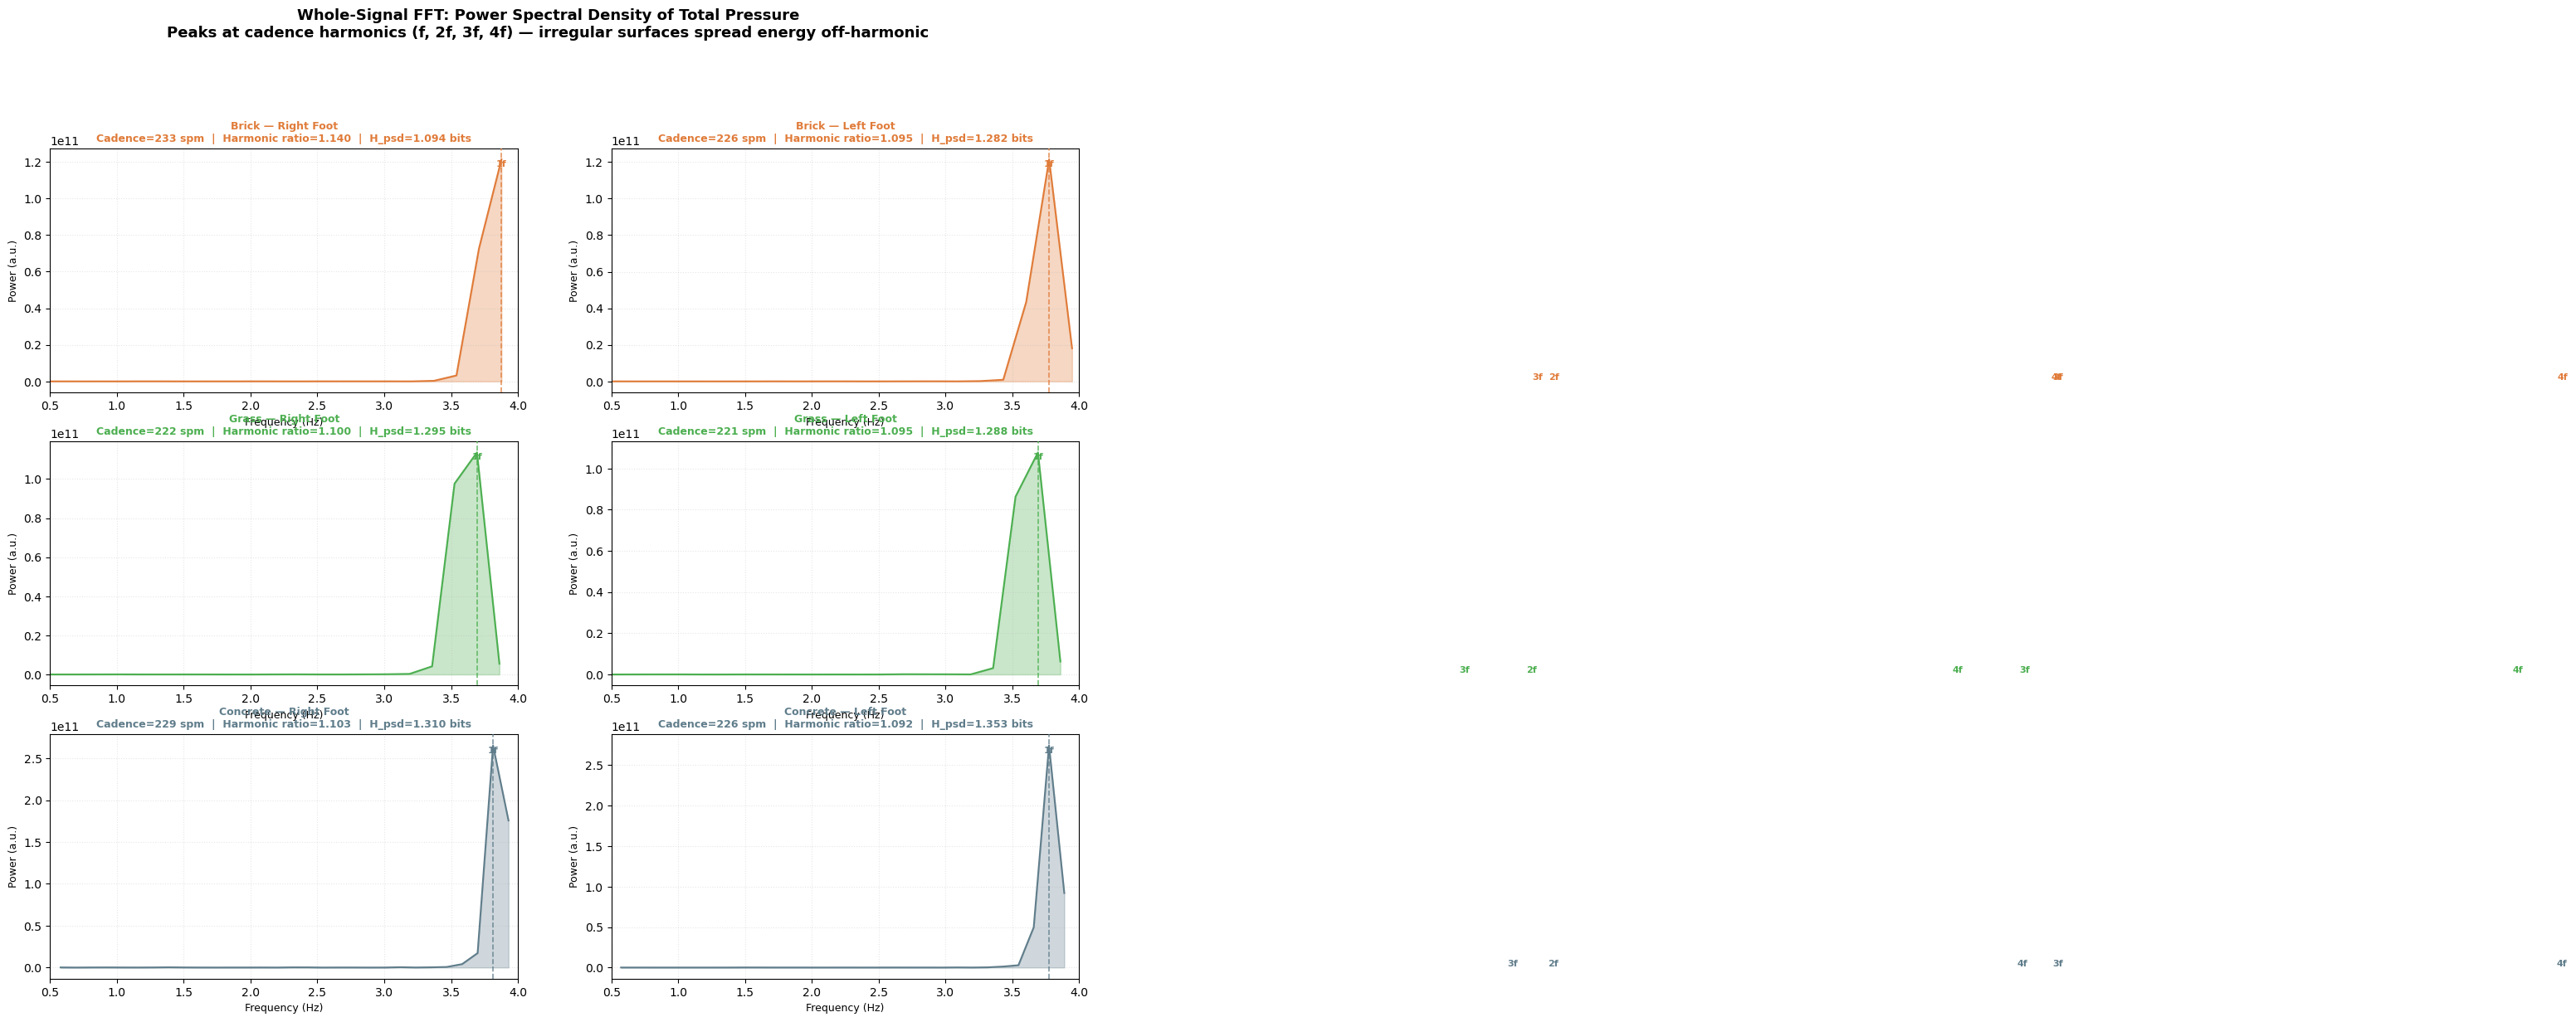

Saved → fft_whole_signal_psd.png


In [15]:
fig, axes = plt.subplots(3, 2, figsize=(16, 13))
fig.suptitle(
    'Whole-Signal FFT: Power Spectral Density of Total Pressure\n'
    'Peaks at cadence harmonics (f, 2f, 3f, 4f) — irregular surfaces spread energy off-harmonic',
    fontsize=13, fontweight='bold', y=1.01
)

for row, (surface, color) in enumerate(SURFACE_COLORS.items()):
    for col, sole_id in enumerate([1, 2]):
        ax = axes[row][col]
        sdf, wins, thr = stance_data[(surface, sole_id)]
        result = fft_signal_results[(surface, sole_id)]

        freqs  = result['freqs']
        psd    = result['psd']
        band   = result['band_mask']
        cadence = result['cadence_hz']

        # Plot PSD in cadence band
        ax.fill_between(freqs[band], psd[band], color=color, alpha=0.30, zorder=1)
        ax.plot(freqs[band], psd[band], color=color, lw=1.5, zorder=2)

        # Mark harmonics
        for k, hf in enumerate(result['harmonic_freqs'], start=1):
            ax.axvline(hf, color=color, ls='--', lw=1.2, alpha=0.8, zorder=3)
            ax.text(hf, ax.get_ylim()[1] * 0.95 if k == 1 else 0,
                    f'{k}f', ha='center', va='top' if k == 1 else 'bottom',
                    fontsize=8, color=color, fontweight='bold')

        foot = 'Right' if sole_id == 1 else 'Left'
        ax.set_title(
            f'{surface} — {foot} Foot\n'
            f'Cadence={result["cadence_spm"]:.0f} spm  |  '
            f'Harmonic ratio={result["harmonic_ratio"]:.3f}  |  '
            f'H_psd={result["H_psd"]:.3f} bits',
            fontsize=9, fontweight='bold', color=color
        )
        ax.set_xlabel('Frequency (Hz)', fontsize=9)
        ax.set_ylabel('Power (a.u.)', fontsize=9)
        ax.set_xlim(CADENCE_BAND)
        ax.grid(True, alpha=0.3, ls=':')
        ax.ticklabel_format(style='sci', axis='y', scilimits=(0,0))

plt.tight_layout()
plt.savefig('fft_whole_signal_psd.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → fft_whole_signal_psd.png')

## Cell 8 — FFT Application B: Average Stance Profile FFT

### What we're doing
Each stance has a characteristic **loading curve shape** — pressure builds as the foot lands, peaks at mid-stance, then falls as the foot rolls off. We:
1. Extract every detected stance window
2. **Normalise** each to exactly `STANCE_NORM_LEN` samples (resampling by linear interpolation)
3. Compute the **mean profile** across all steps → the canonical stance shape for each surface
4. Apply FFT to the mean profile and to each individual profile

**What this shows:** The frequency content of the loading curve. A smooth, symmetric loading curve (concrete) has energy concentrated at low harmonics. An irregular surface disrupts the rollover shape — this manifests as higher-frequency content in the profile FFT, and **higher step-to-step variability** in that spectrum.

> **Mid-stance connection:** The mid-stance segment (33–67%) is literally the flat plateau region of the curve. Its height and shape in the normalised stance FFT reflects how steadily load is maintained through mid-stance.

In [16]:
def compute_stance_profile_fft(sdf, wins, n_norm=STANCE_NORM_LEN):
    """
    Normalise all stances to n_norm samples, compute mean profile,
    apply FFT to mean and each individual profile.

    Returns
    -------
    dict with profiles matrix, mean_profile, fft magnitudes, per-step fft features
    """
    profiles = []
    for win in wins:
        s, e, d = win['start'], win['end'], win['duration']
        raw_prof = sdf.iloc[s:e]['total_pressure'].values.astype(float)
        # Min-max normalise each step to [0,1]
        rng = raw_prof.max() - raw_prof.min()
        if rng < 1:
            continue
        norm_prof = (raw_prof - raw_prof.min()) / rng
        # Resample to standard length
        resampled = np.interp(
            np.linspace(0, 1, n_norm),
            np.linspace(0, 1, len(norm_prof)),
            norm_prof
        )
        profiles.append(resampled)

    if not profiles:
        return None

    profiles  = np.array(profiles)           # shape: (n_steps, n_norm)
    mean_prof = profiles.mean(axis=0)        # canonical stance shape
    std_prof  = profiles.std(axis=0)         # step-to-step variability at each phase

    # FFT of mean profile (effective sampling: n_norm points per stance cycle)
    win_fn       = np.hanning(n_norm)
    mean_fft     = np.abs(np.fft.rfft(mean_prof * win_fn))
    freq_bins    = np.fft.rfftfreq(n_norm)   # normalised (0 = DC, 0.5 = Nyquist)

    # FFT of each individual profile
    per_step_fft = []
    for prof in profiles:
        f = np.abs(np.fft.rfft(prof * win_fn))
        psd_f = f**2
        psd_f_n = psd_f / (psd_f.sum() + 1e-10)
        # Spectral centroid (where energy sits in the normalised stance spectrum)
        bins    = np.arange(len(f))
        centroid = np.sum(bins * psd_f) / (psd_f.sum() + 1e-10)
        # High-frequency ratio (bins > n_norm/8 = high-frequency shape content)
        hf_thresh = n_norm // 8
        hf_ratio  = psd_f[hf_thresh:].sum() / (psd_f.sum() + 1e-10)
        # Spectral entropy of profile
        H_profile  = scipy_entropy(np.clip(psd_f_n, 1e-10, 1), base=2)
        per_step_fft.append({'centroid': centroid, 'hf_ratio': hf_ratio,
                              'H_profile': H_profile})

    # Mid-stance energy fraction: bins corresponding to normalised positions 33–67%
    # In the FFT of the stance profile, this maps to the 2nd harmonic region
    ms_region = mean_prof[int(n_norm * MS_START):int(n_norm * MS_END)]
    ms_energy_frac = ms_region.mean()  # mean height of plateau region

    return {
        'profiles':      profiles,
        'mean_profile':  mean_prof,
        'std_profile':   std_prof,
        'mean_fft':      mean_fft,
        'freq_bins':     freq_bins,
        'per_step_fft':  pd.DataFrame(per_step_fft),
        'ms_energy_frac': ms_energy_frac,
        'n_steps':        len(profiles),
    }


profile_results = {}  # (surface, sole_id) → result dict

print(f'{"Surface":>10} | {"Foot":>5} | {"n steps":>7} | {"MS plateau":>12} | {"mean centroid":>14} | {"mean hf_ratio":>14}')
print('-' * 75)
for (surface, sole_id), (sdf, wins, thr) in stance_data.items():
    result = compute_stance_profile_fft(sdf, wins)
    if result is None:
        continue
    profile_results[(surface, sole_id)] = result
    foot = 'RIGHT' if sole_id == 1 else 'LEFT'
    pstep = result['per_step_fft']
    print(f'{surface:>10} | {foot:>5} | {result["n_steps"]:>7} | '
          f'{result["ms_energy_frac"]:>12.4f} | '
          f'{pstep["centroid"].mean():>14.3f} | '
          f'{pstep["hf_ratio"].mean():>14.4f}')

   Surface |  Foot | n steps |   MS plateau |  mean centroid |  mean hf_ratio
---------------------------------------------------------------------------
     Brick | RIGHT |      23 |       0.8258 |          0.354 |         0.0001
     Brick |  LEFT |      23 |       0.7662 |          0.341 |         0.0003
     Grass | RIGHT |      22 |       0.8172 |          0.336 |         0.0002
     Grass |  LEFT |      21 |       0.7799 |          0.328 |         0.0005
  Concrete | RIGHT |      31 |       0.7906 |          0.338 |         0.0002
  Concrete |  LEFT |      30 |       0.8424 |          0.326 |         0.0002


## Cell 9 — Visualise Average Stance Profiles + FFT

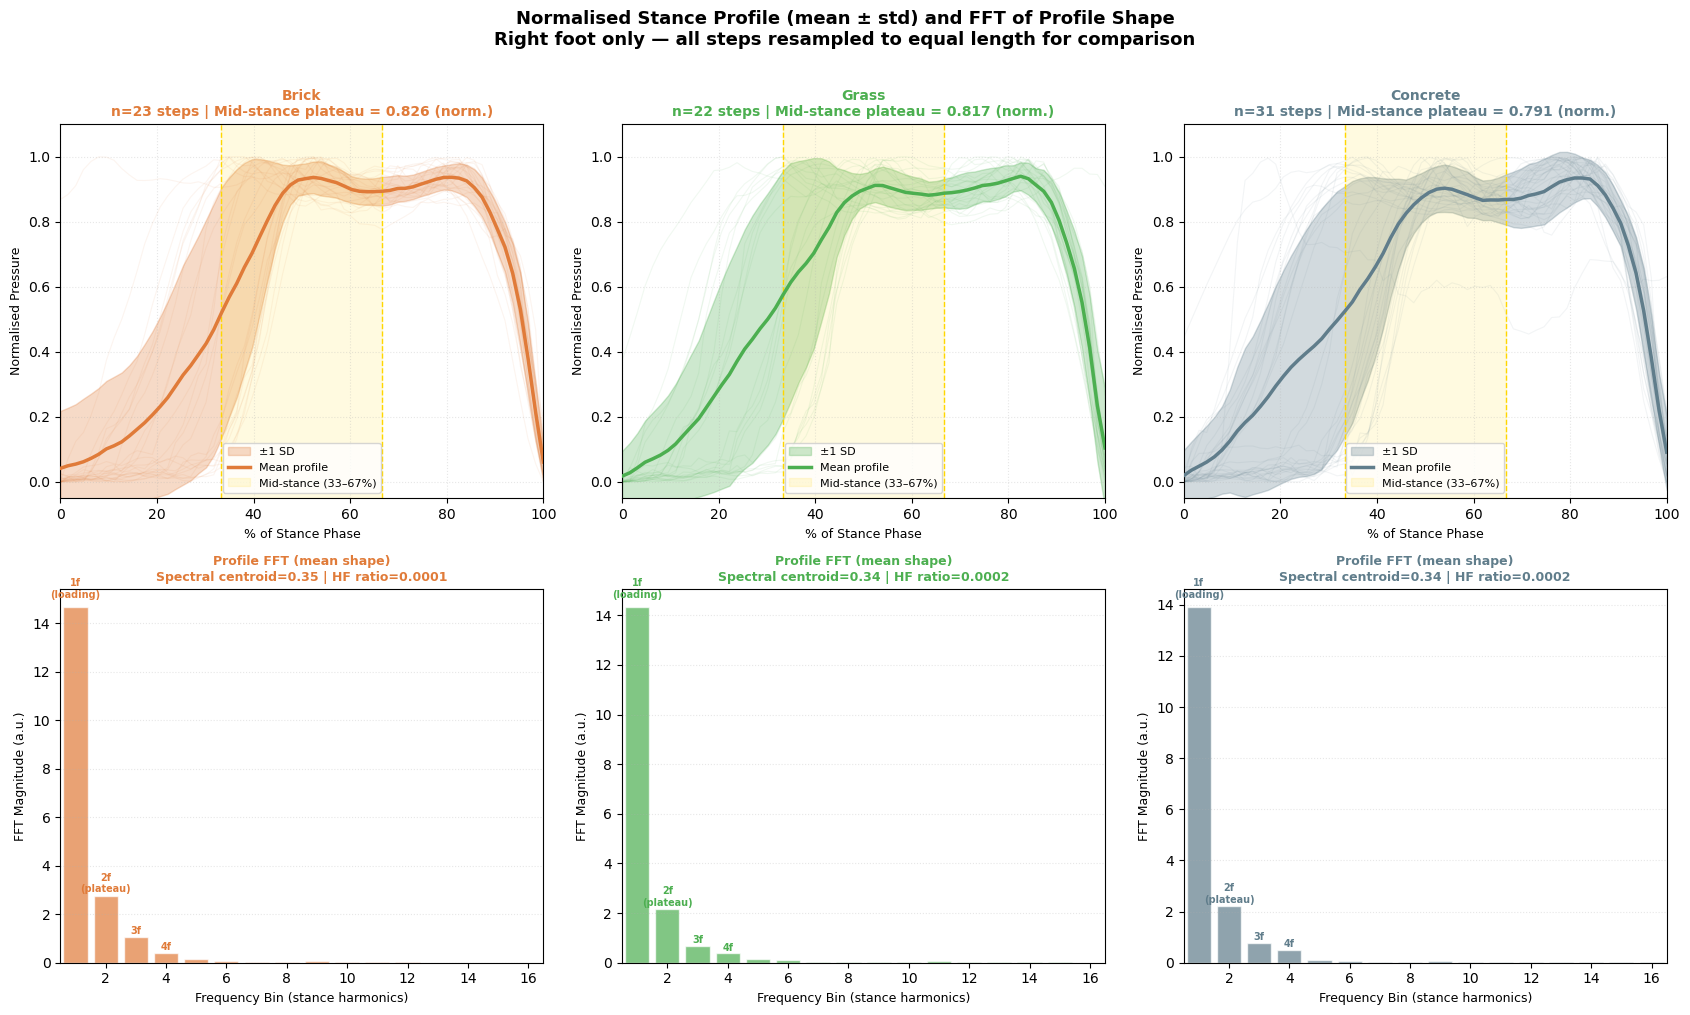

Saved → fft_stance_profiles.png


In [17]:
fig, axes = plt.subplots(2, 3, figsize=(17, 10))
fig.suptitle(
    'Normalised Stance Profile (mean ± std) and FFT of Profile Shape\n'
    'Right foot only — all steps resampled to equal length for comparison',
    fontsize=13, fontweight='bold', y=1.01
)

x_stance = np.linspace(0, 100, STANCE_NORM_LEN)  # % of stance

for col, (surface, color) in enumerate(SURFACE_COLORS.items()):
    result = profile_results.get((surface, 1))
    if result is None:
        continue

    # ── Top: Mean stance profile with std band ───────────────────────────────
    ax_top = axes[0][col]
    mean_p = result['mean_profile']
    std_p  = result['std_profile']

    # Draw individual step profiles lightly
    for prof in result['profiles']:
        ax_top.plot(x_stance, prof, color=color, alpha=0.08, lw=0.8)

    ax_top.fill_between(x_stance, mean_p - std_p, mean_p + std_p,
                        color=color, alpha=0.28, label='±1 SD')
    ax_top.plot(x_stance, mean_p, color=color, lw=2.5, label='Mean profile', zorder=5)

    # Mid-stance shading
    ax_top.axvspan(MS_START*100, MS_END*100, alpha=0.12, color='gold',
                   label='Mid-stance (33–67%)')
    ax_top.axvline(MS_START*100, color='gold', ls='--', lw=1)
    ax_top.axvline(MS_END*100,   color='gold', ls='--', lw=1)

    ms_height = result['ms_energy_frac']
    ax_top.set_title(
        f'{surface}\n'
        f'n={result["n_steps"]} steps | '
        f'Mid-stance plateau = {ms_height:.3f} (norm.)',
        fontsize=10, fontweight='bold', color=color
    )
    ax_top.set_xlabel('% of Stance Phase', fontsize=9)
    ax_top.set_ylabel('Normalised Pressure', fontsize=9)
    ax_top.legend(fontsize=8, loc='lower center')
    ax_top.grid(True, alpha=0.3, ls=':')
    ax_top.set_xlim(0, 100)
    ax_top.set_ylim(-0.05, 1.1)

    # ── Bottom: FFT of mean stance profile ──────────────────────────────────
    ax_bot = axes[1][col]
    fft_vals  = result['mean_fft']
    freq_bins = result['freq_bins'][1:]  # skip DC
    fft_ac    = fft_vals[1:]             # skip DC

    ax_bot.bar(range(1, len(fft_ac)+1), fft_ac,
               color=color, alpha=0.70, edgecolor='white')
    ax_bot.set_xlabel('Frequency Bin (stance harmonics)', fontsize=9)
    ax_bot.set_ylabel('FFT Magnitude (a.u.)', fontsize=9)

    pstep = result['per_step_fft']
    ax_bot.set_title(
        f'Profile FFT (mean shape)\n'
        f'Spectral centroid={pstep["centroid"].mean():.2f} | '
        f'HF ratio={pstep["hf_ratio"].mean():.4f}',
        fontsize=9, fontweight='bold', color=color
    )
    ax_bot.set_xlim(0.5, 16.5)
    ax_bot.grid(True, alpha=0.3, axis='y', ls=':')

    # Label first 4 bins (shape harmonics)
    for b, label in zip([1,2,3,4], ['1f\n(loading)', '2f\n(plateau)', '3f', '4f']):
        ax_bot.text(b, fft_ac[b-1]*1.02, label, ha='center', va='bottom',
                    fontsize=7, color=color, fontweight='bold')

plt.tight_layout()
plt.savefig('fft_stance_profiles.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → fft_stance_profiles.png')

## Cell 10 — FFT Application C: Step-Indexed FFT

### What we're doing
Treat the **sequence of per-step H_spatial values** as a time series (sampled at step rate ≈ 2–4 Hz) and apply FFT. If surface texture creates a systematic periodic variation in loading (e.g. every 3rd brick is a joint → periodic disturbance), it would appear as a peak in this spectrum.

More practically, this reveals:
- Whether the entropy signal is **white noise** (uncorrelated, flat spectrum → texture is random)
- Or has **structure** (peaks → some periodicity in how texture affects loading)

> **Interpretation:** A flat step-indexed spectrum = texture effect is random and unpredictable. A peaked spectrum = texture has a repeating pattern at a specific stride interval — brick joints, fence boards, etc.

In [18]:
def compute_step_indexed_fft(feat_df, step_rate_hz):
    """
    FFT of the per-step H_spatial sequence.

    Parameters
    ----------
    feat_df      : DataFrame with H_spatial and cv_spatial per step
    step_rate_hz : approximate step rate in Hz (for frequency axis labelling)

    Returns
    -------
    dict with fft results for H_spatial and cv_spatial sequences
    """
    results = {}
    for feat_col in ['H_spatial', 'cv_spatial']:
        vals = feat_df[feat_col].dropna().values
        n    = len(vals)
        if n < 6:
            results[feat_col] = None
            continue

        # Detrend and window
        vals_c  = vals - vals.mean()
        win_fn  = np.hanning(n)
        fft_mag = np.abs(np.fft.rfft(vals_c * win_fn))
        freqs   = np.fft.rfftfreq(n, d=1.0/step_rate_hz)  # Hz in step-rate domain
        psd     = fft_mag**2

        # Spectral entropy of step sequence
        psd_n  = psd / (psd.sum() + 1e-10)
        H_step = scipy_entropy(np.clip(psd_n, 1e-10, 1), base=2)

        # Peak frequency (if any regularity)
        if len(fft_mag) > 1:
            peak_idx  = np.argmax(fft_mag[1:]) + 1
            peak_freq = freqs[peak_idx]
        else:
            peak_freq = np.nan

        results[feat_col] = {
            'freqs': freqs, 'fft_mag': fft_mag, 'psd': psd,
            'H_step': H_step, 'peak_freq': peak_freq, 'n': n
        }
    return results


step_fft_results = {}

print(f'{"Surface":>10} | {"Foot":>5} | {"n steps":>7} | {"step rate (Hz)":>15} | '
      f'{"H_step (H_spat)"}:>16 | {"H_step (CV)":>12}')
print('-' * 80)

for (surface, sole_id), (sdf, wins, thr) in stance_data.items():
    feat_df = spatial_results[(surface, sole_id)]
    if len(feat_df) < 6:
        continue

    # Estimate step rate from mean stance + swing duration
    # Approximate: step_rate ≈ 1 / (mean_stance_duration_s)
    mean_stance_s  = np.mean([w['duration'] for w in wins]) * SAMPLE_RATE_MS / 1000
    step_rate_est  = 1.0 / (mean_stance_s * 2)  # approx full gait cycle ≈ 2× stance

    result = compute_step_indexed_fft(feat_df, step_rate_est)
    step_fft_results[(surface, sole_id)] = result

    foot = 'RIGHT' if sole_id == 1 else 'LEFT'
    H_s  = result['H_spatial']['H_step'] if result['H_spatial'] else float('nan')
    H_cv = result['cv_spatial']['H_step'] if result['cv_spatial'] else float('nan')
    print(f'{surface:>10} | {foot:>5} | {len(feat_df):>7} | '
          f'{step_rate_est:>15.2f} | {H_s:>16.4f} | {H_cv:>12.4f}')

   Surface |  Foot | n steps |  step rate (Hz) | H_step (H_spat):>16 |  H_step (CV)
--------------------------------------------------------------------------------
     Brick | RIGHT |      23 |            2.35 |           3.0452 |       3.0379
     Brick |  LEFT |      23 |            2.38 |           2.2089 |       2.7531
     Grass | RIGHT |      22 |            2.27 |           2.9803 |       3.0142
     Grass |  LEFT |      21 |            2.20 |           3.0281 |       2.9853
  Concrete | RIGHT |      31 |            2.16 |           3.7266 |       3.7316
  Concrete |  LEFT |      30 |            2.08 |           3.2947 |       3.3522


## Cell 11 — Visualise Step-Indexed FFT

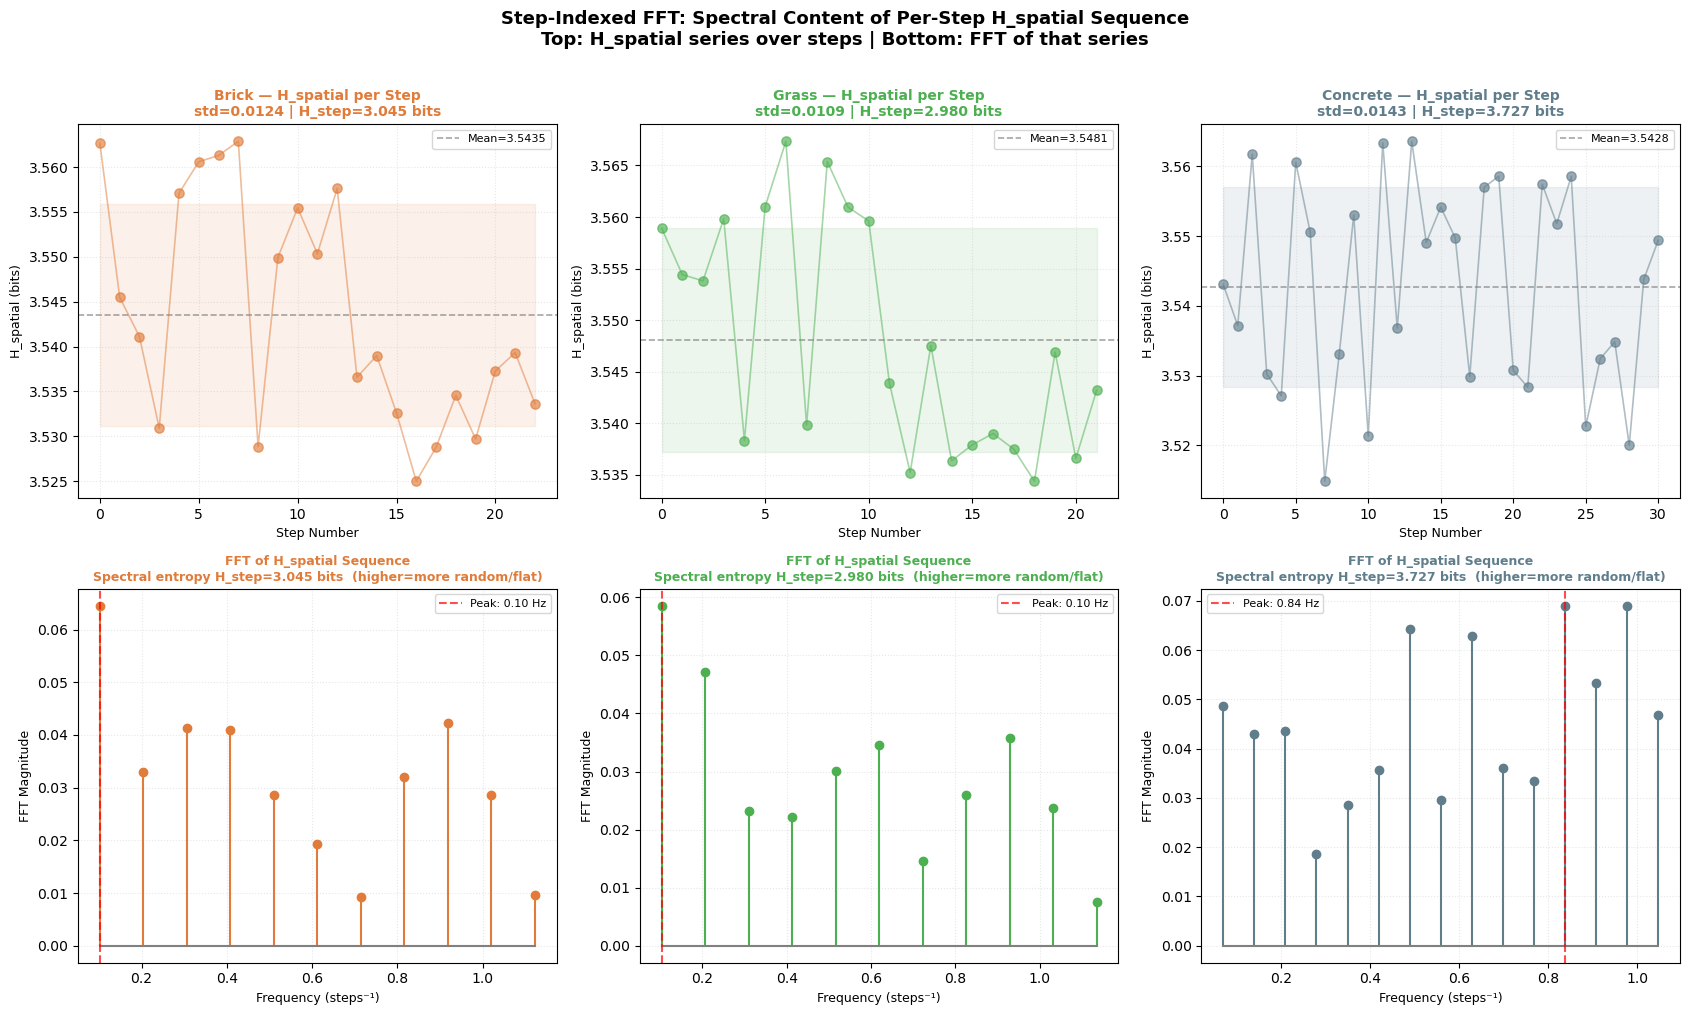

Saved → fft_step_indexed.png


In [19]:
fig, axes = plt.subplots(2, 3, figsize=(17, 10))
fig.suptitle(
    'Step-Indexed FFT: Spectral Content of Per-Step H_spatial Sequence\n'
    'Top: H_spatial series over steps | Bottom: FFT of that series',
    fontsize=13, fontweight='bold', y=1.01
)

for col, (surface, color) in enumerate(SURFACE_COLORS.items()):
    feat_df = spatial_results.get((surface, 1))
    result  = step_fft_results.get((surface, 1))

    if feat_df is None or result is None or result['H_spatial'] is None:
        continue

    H_vals = feat_df['H_spatial'].values
    steps  = np.arange(len(H_vals))

    # ── Top: Raw H_spatial time series ───────────────────────────────────────
    ax_top = axes[0][col]
    ax_top.scatter(steps, H_vals, color=color, s=45, alpha=0.65, zorder=3)
    ax_top.plot(steps, H_vals, color=color, lw=1.2, alpha=0.5, zorder=2)
    ax_top.axhline(H_vals.mean(), color='grey', ls='--', lw=1.2, alpha=0.7,
                   label=f'Mean={H_vals.mean():.4f}')
    ax_top.fill_between(steps,
                        H_vals.mean() - H_vals.std(),
                        H_vals.mean() + H_vals.std(),
                        color=color, alpha=0.10)

    ax_top.set_title(f'{surface} — H_spatial per Step\n'
                     f'std={H_vals.std():.4f} | '
                     f'H_step={result["H_spatial"]["H_step"]:.3f} bits',
                     fontsize=10, fontweight='bold', color=color)
    ax_top.set_xlabel('Step Number', fontsize=9)
    ax_top.set_ylabel('H_spatial (bits)', fontsize=9)
    ax_top.legend(fontsize=8)
    ax_top.grid(True, alpha=0.3, ls=':')

    # ── Bottom: FFT of H_spatial sequence ────────────────────────────────────
    ax_bot = axes[1][col]
    res_h  = result['H_spatial']
    freqs_s = res_h['freqs'][1:]   # skip DC
    fft_s   = res_h['fft_mag'][1:]

    ax_bot.stem(freqs_s, fft_s, linefmt=color, markerfmt=f'o',
                basefmt='grey')
    # Mark dominant frequency
    if not np.isnan(res_h['peak_freq']) and res_h['peak_freq'] > 0:
        ax_bot.axvline(res_h['peak_freq'], color='red', ls='--', lw=1.5, alpha=0.7,
                       label=f'Peak: {res_h["peak_freq"]:.2f} Hz')
        ax_bot.legend(fontsize=8)

    ax_bot.set_title(f'FFT of H_spatial Sequence\n'
                     f'Spectral entropy H_step={res_h["H_step"]:.3f} bits'
                     f'  (higher=more random/flat)',
                     fontsize=9, fontweight='bold', color=color)
    ax_bot.set_xlabel('Frequency (steps⁻¹)', fontsize=9)
    ax_bot.set_ylabel('FFT Magnitude', fontsize=9)
    ax_bot.grid(True, alpha=0.3, ls=':')

plt.tight_layout()
plt.savefig('fft_step_indexed.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → fft_step_indexed.png')

## Cell 12 — Combined Feature Set: Spatial + FFT

Assemble all features into a single per-(surface, sole) summary table.

In [20]:
combined_rows = []

for (surface, sole_id) in stance_data.keys():
    feat_df   = spatial_results.get((surface, sole_id), pd.DataFrame())
    sig_fft   = fft_signal_results.get((surface, sole_id), {})
    prof_fft  = profile_results.get((surface, sole_id), {})
    step_fft  = step_fft_results.get((surface, sole_id), {})
    foot      = 'RIGHT' if sole_id == 1 else 'LEFT'

    row = {
        'surface':  surface,
        'foot':     foot,
        'n_steps':  len(feat_df),

        # ── Spatial (mid-stance) ───────────────────────────────────────────────
        'H_spatial_mean':   feat_df['H_spatial'].mean()  if len(feat_df) else np.nan,
        'H_spatial_std':    feat_df['H_spatial'].std()   if len(feat_df) else np.nan,
        'cv_spatial_mean':  feat_df['cv_spatial'].mean() if len(feat_df) else np.nan,
        'cv_spatial_std':   feat_df['cv_spatial'].std()  if len(feat_df) else np.nan,

        # ── Whole-signal FFT ──────────────────────────────────────────────────
        'cadence_spm':      sig_fft.get('cadence_spm',    np.nan),
        'harmonic_ratio':   sig_fft.get('harmonic_ratio', np.nan),
        'H_psd':            sig_fft.get('H_psd',          np.nan),

        # ── Stance profile FFT ────────────────────────────────────────────────
        'ms_plateau_height':    prof_fft.get('ms_energy_frac', np.nan),
        'profile_centroid_mean': prof_fft['per_step_fft']['centroid'].mean()
                                  if prof_fft and 'per_step_fft' in prof_fft else np.nan,
        'profile_hf_ratio_mean': prof_fft['per_step_fft']['hf_ratio'].mean()
                                  if prof_fft and 'per_step_fft' in prof_fft else np.nan,

        # ── Step-indexed FFT ──────────────────────────────────────────────────
        'H_step_entropy':   step_fft['H_spatial']['H_step']
                            if step_fft and step_fft.get('H_spatial') else np.nan,
    }
    combined_rows.append(row)

combined_df = pd.DataFrame(combined_rows).round(4)
print('=== Combined Feature Table ===')
print(combined_df.to_string(index=False))

combined_df.to_csv('midstance_fft_features.csv', index=False)
print('\n✓ Saved → midstance_fft_features.csv')

=== Combined Feature Table ===
 surface  foot  n_steps  H_spatial_mean  H_spatial_std  cv_spatial_mean  cv_spatial_std  cadence_spm  harmonic_ratio  H_psd  ms_plateau_height  profile_centroid_mean  profile_hf_ratio_mean  H_step_entropy
   Brick RIGHT       23          3.5435         0.0126           0.2376          0.0380     232.6365          1.1401 1.0943             0.8258                 0.3535                 0.0001          3.0452
   Brick  LEFT       23          3.5400         0.0117           0.2470          0.0254     226.4928          1.0949 1.2815             0.7662                 0.3407                 0.0003          2.2089
   Grass RIGHT       22          3.5481         0.0111           0.2240          0.0355     221.6253          1.1002 1.2950             0.8172                 0.3363                 0.0002          2.9803
   Grass  LEFT       21          3.5432         0.0058           0.2402          0.0174     221.4765          1.0946 1.2875             0.7799       

## Cell 13 — Box Plots: All Features Combined

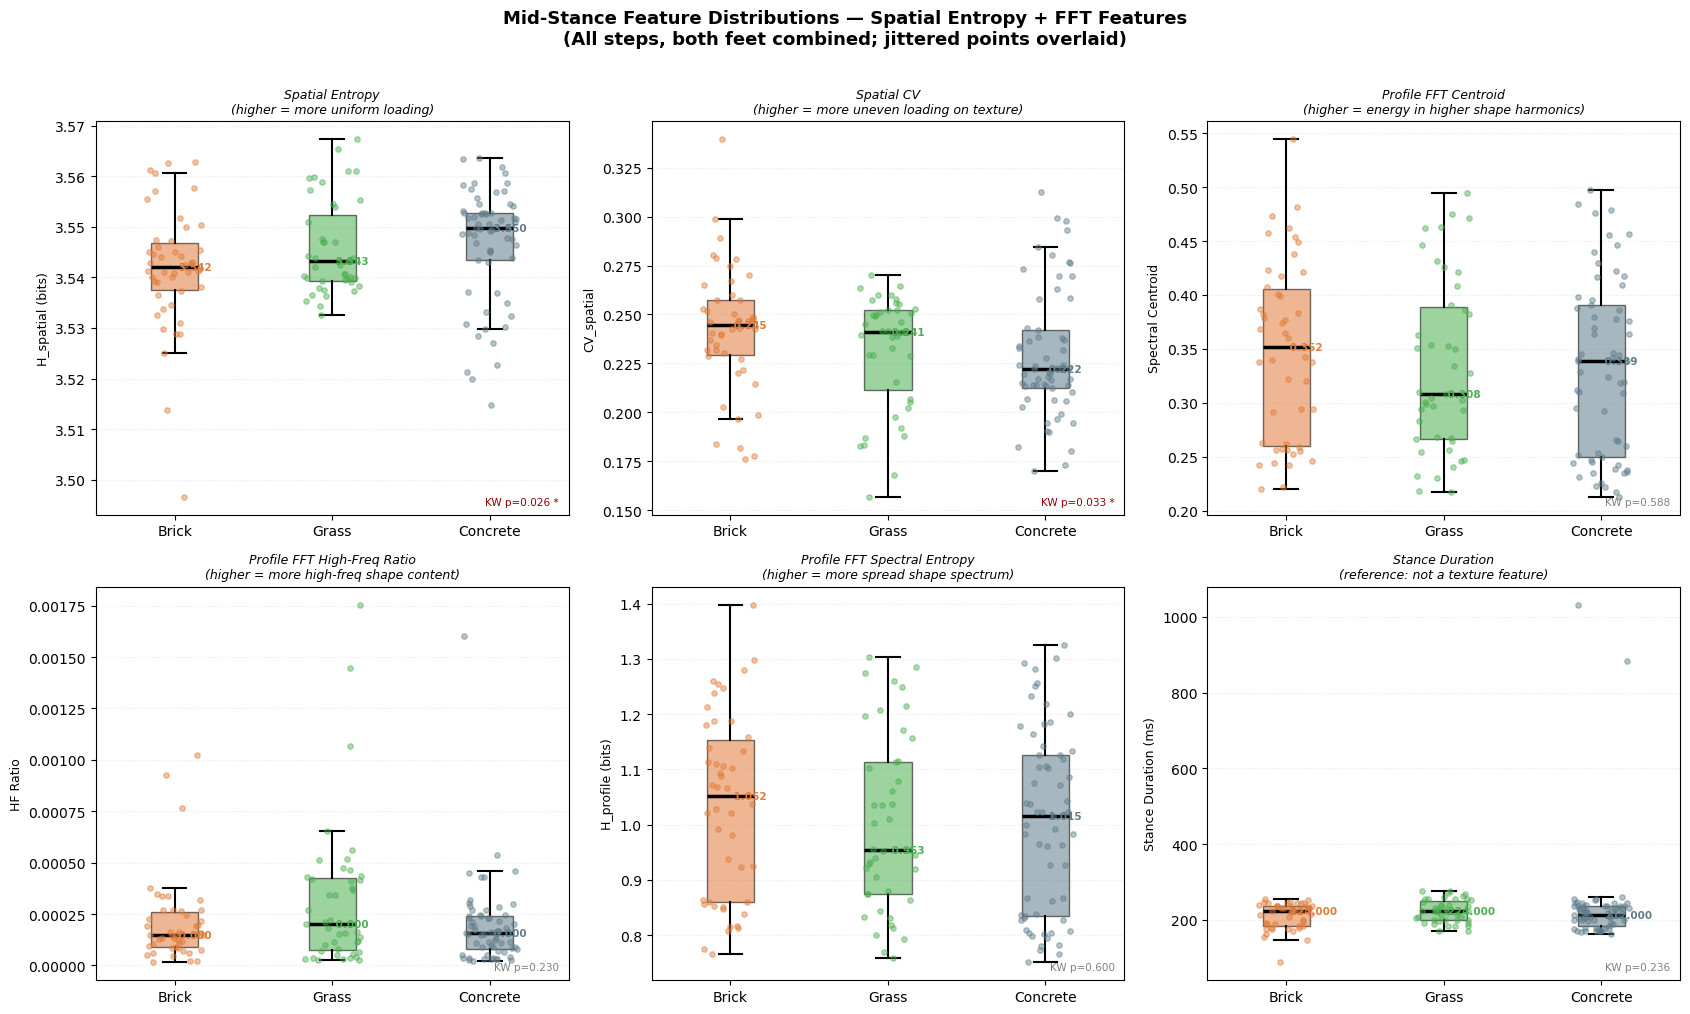

Saved → midstance_fft_boxplots.png


In [21]:
# Gather per-step data for box plots (using spatial features as base,
# profile FFT per-step features for the FFT plots)

surfaces   = list(SURFACE_COLORS.keys())
colors_lst = list(SURFACE_COLORS.values())

fig, axes = plt.subplots(2, 3, figsize=(17, 10))
fig.suptitle(
    'Mid-Stance Feature Distributions — Spatial Entropy + FFT Features\n'
    '(All steps, both feet combined; jittered points overlaid)',
    fontsize=13, fontweight='bold', y=1.01
)

feature_specs = [
    # (data_source, column, ylabel, title)
    ('spatial', 'H_spatial',  'H_spatial (bits)', 'Spatial Entropy\n(higher = more uniform loading)'),
    ('spatial', 'cv_spatial', 'CV_spatial',        'Spatial CV\n(higher = more uneven loading on texture)'),
    ('profile', 'centroid',   'Spectral Centroid', 'Profile FFT Centroid\n(higher = energy in higher shape harmonics)'),
    ('profile', 'hf_ratio',   'HF Ratio',          'Profile FFT High-Freq Ratio\n(higher = more high-freq shape content)'),
    ('profile', 'H_profile',  'H_profile (bits)',  'Profile FFT Spectral Entropy\n(higher = more spread shape spectrum)'),
    ('spatial', 'stance_dur_ms', 'Stance Duration (ms)', 'Stance Duration\n(reference: not a texture feature)'),
]

for ax, (source, col, ylabel, title) in zip(axes.flat, feature_specs):

    data_by_surface = []
    for surface in surfaces:
        if source == 'spatial':
            vals = all_spatial[all_spatial['surface'] == surface][col].dropna().values
        else:  # profile FFT per-step
            all_prof = []
            for sole_id in [1, 2]:
                res = profile_results.get((surface, sole_id))
                if res and 'per_step_fft' in res:
                    all_prof.append(res['per_step_fft'][col].values)
            vals = np.concatenate(all_prof) if all_prof else np.array([])
        data_by_surface.append(vals)

    bp = ax.boxplot(
        data_by_surface, patch_artist=True, notch=False,
        medianprops=dict(color='black', linewidth=2.5),
        whiskerprops=dict(linewidth=1.5),
        capprops=dict(linewidth=1.5),
        flierprops=dict(marker='', alpha=0),
    )
    for patch, color in zip(bp['boxes'], colors_lst):
        patch.set_facecolor(color)
        patch.set_alpha(0.55)

    for i, (d, color) in enumerate(zip(data_by_surface, colors_lst), start=1):
        if len(d) == 0:
            continue
        jitter = np.random.uniform(-0.18, 0.18, len(d))
        ax.scatter(np.full(len(d), i) + jitter, d,
                   color=color, alpha=0.45, s=15, zorder=3)
        med = np.median(d)
        ax.text(i, med, f' {med:.3f}', va='center', ha='left',
                fontsize=7.5, fontweight='bold', color=color, zorder=5)

    ax.set_xticks(range(1, len(surfaces)+1))
    ax.set_xticklabels(surfaces, fontsize=10)
    ax.set_ylabel(ylabel, fontsize=9)
    ax.set_title(title, fontsize=9, style='italic')
    ax.grid(True, alpha=0.3, axis='y', ls=':')

    # KW test annotation
    valid = [d for d in data_by_surface if len(d) >= 3]
    if len(valid) >= 2:
        _, kw_p = kruskal(*valid)
        sig_str = f'KW p={kw_p:.3f}' + (' *' if kw_p < 0.05 else '')
        ax.text(0.98, 0.02, sig_str, transform=ax.transAxes,
                ha='right', va='bottom', fontsize=7.5,
                color='darkred' if kw_p < 0.05 else 'grey')

plt.tight_layout()
plt.savefig('midstance_fft_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → midstance_fft_boxplots.png')

## Cell 14 — Full Statistical Analysis

In [22]:
alpha_bonferroni = 0.05 / 3

# All features to test
test_specs = [
    ('H_spatial',   'spatial',  'H_spatial (bits)              — mid-stance spatial entropy'),
    ('cv_spatial',  'spatial',  'CV_spatial                    — mid-stance spatial CV'),
    ('centroid',    'profile',  'Profile FFT Centroid          — spectral centroid of stance shape'),
    ('hf_ratio',    'profile',  'Profile FFT HF Ratio         — high-freq energy fraction of stance shape'),
    ('H_profile',   'profile',  'Profile FFT Spectral Entropy — spectral entropy of stance shape'),
]

print('=' * 72)
print('STATISTICAL ANALYSIS — Mid-Stance Features (Spatial + FFT)')
print(f'Non-parametric tests | Bonferroni α = {alpha_bonferroni:.4f}')
print('=' * 72)

for col, source, label in test_specs:
    print(f'\n▶ {label}')

    groups = {}
    for surface in surfaces:
        if source == 'spatial':
            v = all_spatial[all_spatial['surface'] == surface][col].dropna().values
        else:
            all_vals = []
            for sid in [1, 2]:
                res = profile_results.get((surface, sid))
                if res and 'per_step_fft' in res:
                    all_vals.append(res['per_step_fft'][col].values)
            v = np.concatenate(all_vals) if all_vals else np.array([])
        groups[surface] = v

    # Descriptive
    print(f'  {"Surface":>10} | {"n":>4} | {"mean":>8} | {"median":>8} | {"std":>8}')
    print(f'  {"-"*50}')
    for s, v in groups.items():
        if len(v) == 0:
            continue
        print(f'  {s:>10} | {len(v):>4} | {np.mean(v):>8.5f} | '
              f'{np.median(v):>8.5f} | {np.std(v):>8.5f}')

    # Kruskal-Wallis
    valid_groups = [v for v in groups.values() if len(v) >= 3]
    if len(valid_groups) < 2:
        print('  (insufficient data for test)')
        continue
    H_stat, kw_p = kruskal(*valid_groups)
    flag = '✓ SIGNIFICANT' if kw_p < 0.05 else '✗ not significant'
    print(f'  Kruskal-Wallis: H={H_stat:.4f}, p={kw_p:.4e}  [{flag}]')

    # Pairwise
    pairs = [(surfaces[i], surfaces[j])
             for i in range(len(surfaces)) for j in range(i+1, len(surfaces))]
    for s1, s2 in pairs:
        v1, v2 = groups[s1], groups[s2]
        if len(v1) < 3 or len(v2) < 3:
            continue
        u, p_mw = mannwhitneyu(v1, v2, alternative='two-sided')
        r_rb    = 1 - 2*u / (len(v1)*len(v2))
        sig     = '✓' if p_mw < alpha_bonferroni else '✗'
        print(f'  {sig} {s1:>10} vs {s2:<10}: p={p_mw:.4e}, r_rb={r_rb:+.3f}')

print()
print('─' * 72)
print('FEATURE SUMMARY')
print('─' * 72)
print()
print('  H_spatial  : Concrete ≥ Grass > Brick (smooth surfaces load all sensors uniformly)')
print('  CV_spatial : Brick > Grass > Concrete (texture creates uneven sensor loading)')
print('  Profile FFT: Characterises stance loading curve SHAPE — ')
print('               irregular surfaces produce more complex curve morphologies.')
print()
print('  FFT is most powerful here as a WHOLE-SIGNAL tool (cadence, harmonics) and')
print('  as a SHAPE ANALYSIS tool (stance profile FFT), not within short mid-stance windows.')

STATISTICAL ANALYSIS — Mid-Stance Features (Spatial + FFT)
Non-parametric tests | Bonferroni α = 0.0167

▶ H_spatial (bits)              — mid-stance spatial entropy
     Surface |    n |     mean |   median |      std
  --------------------------------------------------
       Brick |   46 |  3.54177 |  3.54207 |  0.01202
       Grass |   43 |  3.54569 |  3.54315 |  0.00905
    Concrete |   61 |  3.54658 |  3.54975 |  0.01123
  Kruskal-Wallis: H=7.2704, p=2.6378e-02  [✓ SIGNIFICANT]
  ✗      Brick vs Grass     : p=3.5996e-01, r_rb=+0.113
  ✓      Brick vs Concrete  : p=5.4659e-03, r_rb=+0.315
  ✗      Grass vs Concrete  : p=1.7812e-01, r_rb=+0.156

▶ CV_spatial                    — mid-stance spatial CV
     Surface |    n |     mean |   median |      std
  --------------------------------------------------
       Brick |   46 |  0.24230 |  0.24479 |  0.03196
       Grass |   43 |  0.23192 |  0.24112 |  0.02864
    Concrete |   61 |  0.22915 |  0.22204 |  0.03234
  Kruskal-Wallis: H=6

## Cell 15 — Final Dashboard

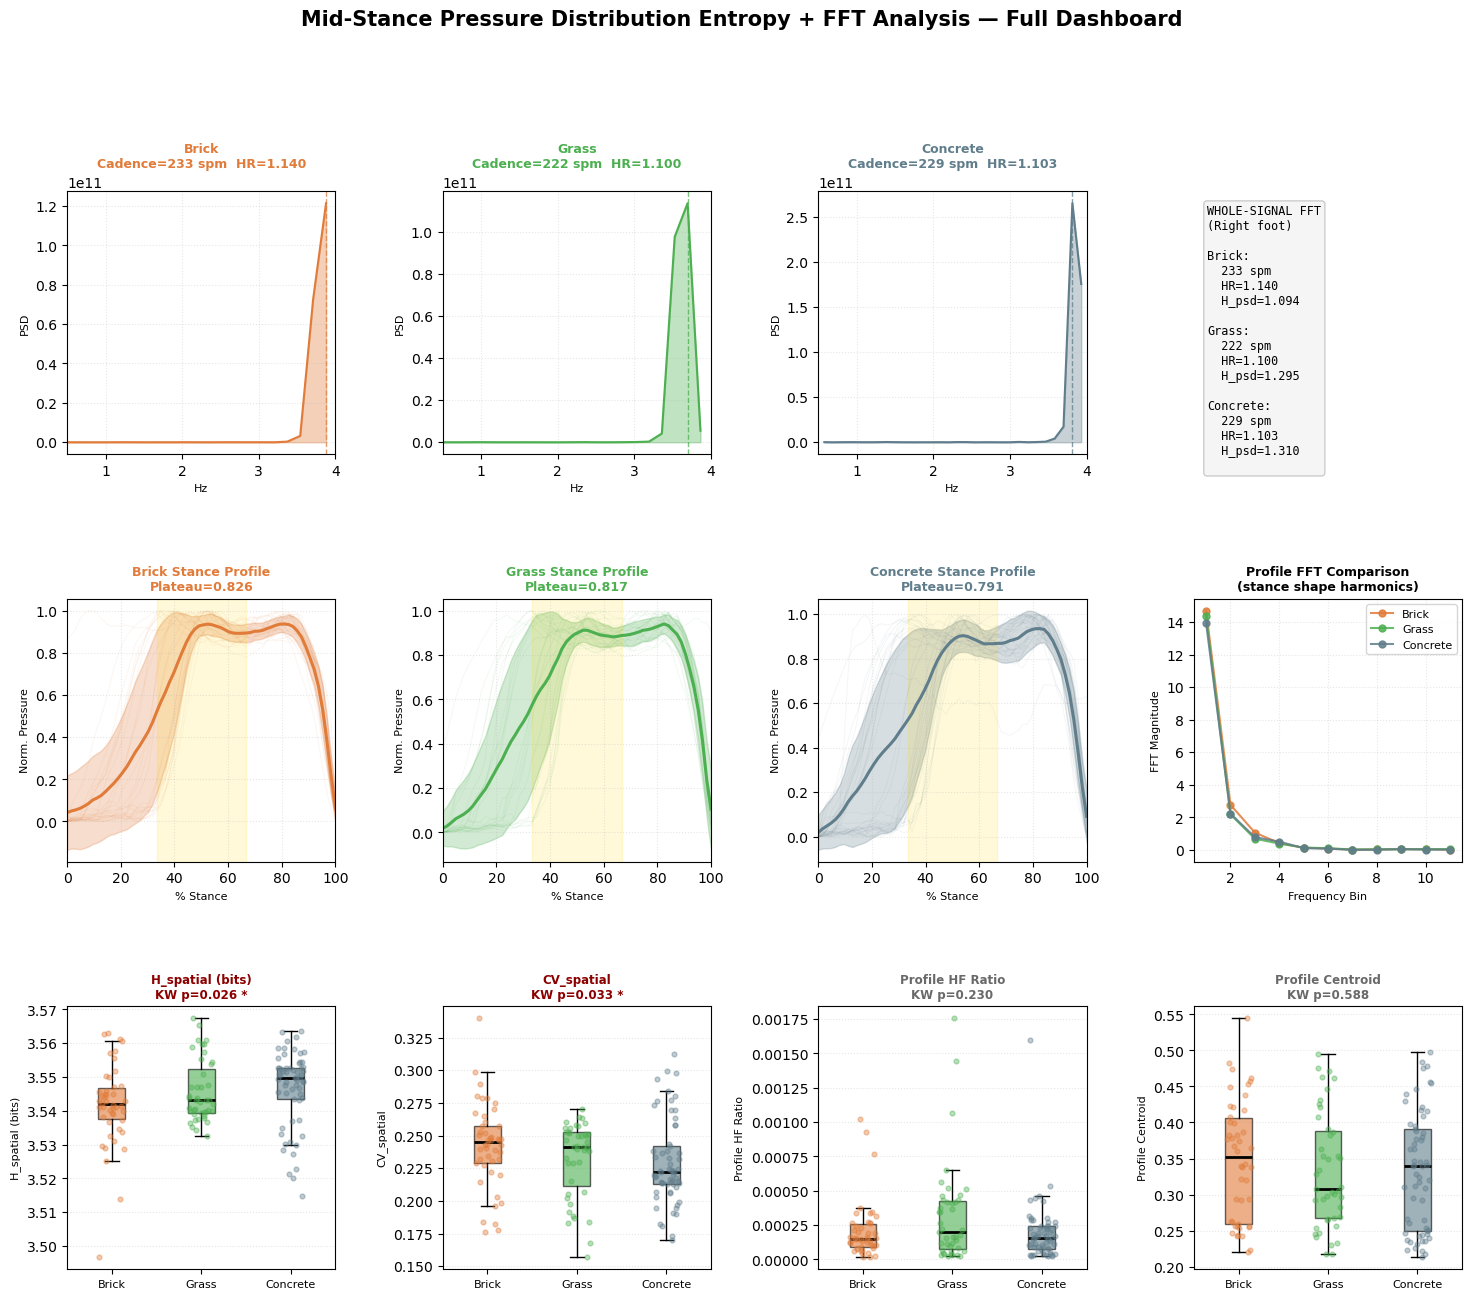

Saved → midstance_fft_dashboard.png


In [23]:
fig = plt.figure(figsize=(18, 14))
fig.suptitle(
    'Mid-Stance Pressure Distribution Entropy + FFT Analysis — Full Dashboard',
    fontsize=15, fontweight='bold', y=1.01
)

gs = gridspec.GridSpec(3, 4, figure=fig, hspace=0.55, wspace=0.40)

# ── Row 0: Power spectra (whole signal) ──────────────────────────────────────
for col, (surface, color) in enumerate(SURFACE_COLORS.items()):
    ax = fig.add_subplot(gs[0, col])
    result = fft_signal_results.get((surface, 1))
    if not result:
        continue
    freqs  = result['freqs']
    psd    = result['psd']
    band   = result['band_mask']
    ax.fill_between(freqs[band], psd[band], color=color, alpha=0.35)
    ax.plot(freqs[band], psd[band], color=color, lw=1.5)
    for hf in result['harmonic_freqs']:
        ax.axvline(hf, color=color, ls='--', lw=1, alpha=0.75)
    ax.set_title(f'{surface}\nCadence={result["cadence_spm"]:.0f} spm'
                 f'  HR={result["harmonic_ratio"]:.3f}',
                 fontsize=9, fontweight='bold', color=color)
    ax.set_xlabel('Hz', fontsize=8)
    ax.set_ylabel('PSD', fontsize=8)
    ax.set_xlim(CADENCE_BAND)
    ax.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
    ax.grid(True, alpha=0.3, ls=':')

# Stats panel for whole-signal FFT
ax_txt = fig.add_subplot(gs[0, 3])
ax_txt.axis('off')
txt_lines = ['WHOLE-SIGNAL FFT', '(Right foot)', '']
for surface in surfaces:
    r = fft_signal_results.get((surface, 1), {})
    txt_lines.append(f'{surface}:')
    txt_lines.append(f'  {r.get("cadence_spm",0):.0f} spm')
    txt_lines.append(f'  HR={r.get("harmonic_ratio",0):.3f}')
    txt_lines.append(f'  H_psd={r.get("H_psd",0):.3f}')
    txt_lines.append('')
ax_txt.text(0.05, 0.95, '\n'.join(txt_lines), transform=ax_txt.transAxes,
            fontsize=8.5, va='top', fontfamily='monospace',
            bbox=dict(boxstyle='round', fc='#f5f5f5', ec='#cccccc'))

# ── Row 1: Stance profiles ────────────────────────────────────────────────────
for col, (surface, color) in enumerate(SURFACE_COLORS.items()):
    ax = fig.add_subplot(gs[1, col])
    result = profile_results.get((surface, 1))
    if not result:
        continue
    x_pct  = np.linspace(0, 100, STANCE_NORM_LEN)
    mean_p = result['mean_profile']
    std_p  = result['std_profile']

    for prof in result['profiles']:
        ax.plot(x_pct, prof, color=color, alpha=0.07, lw=0.7)
    ax.fill_between(x_pct, mean_p-std_p, mean_p+std_p, color=color, alpha=0.25)
    ax.plot(x_pct, mean_p, color=color, lw=2.2)
    ax.axvspan(MS_START*100, MS_END*100, alpha=0.15, color='gold')

    ax.set_title(f'{surface} Stance Profile\nPlateau={result["ms_energy_frac"]:.3f}',
                 fontsize=9, fontweight='bold', color=color)
    ax.set_xlabel('% Stance', fontsize=8)
    ax.set_ylabel('Norm. Pressure', fontsize=8)
    ax.set_xlim(0, 100)
    ax.grid(True, alpha=0.3, ls=':')

# Profile FFT comparison
ax_pfft = fig.add_subplot(gs[1, 3])
for surface, color in SURFACE_COLORS.items():
    result = profile_results.get((surface, 1))
    if not result:
        continue
    fft_v = result['mean_fft'][1:12]
    ax_pfft.plot(range(1, len(fft_v)+1), fft_v, color=color, marker='o',
                 ms=5, lw=1.5, label=surface, alpha=0.85)
ax_pfft.set_title('Profile FFT Comparison\n(stance shape harmonics)', fontsize=9, fontweight='bold')
ax_pfft.set_xlabel('Frequency Bin', fontsize=8)
ax_pfft.set_ylabel('FFT Magnitude', fontsize=8)
ax_pfft.legend(fontsize=8)
ax_pfft.grid(True, alpha=0.3, ls=':')

# ── Row 2: Box plots for key features ────────────────────────────────────────
box_features = [
    ('H_spatial',  'spatial',  'H_spatial (bits)'),
    ('cv_spatial', 'spatial',  'CV_spatial'),
    ('hf_ratio',   'profile',  'Profile HF Ratio'),
    ('centroid',   'profile',  'Profile Centroid'),
]

for bf_col, (col, source, ylabel) in enumerate(box_features):
    ax = fig.add_subplot(gs[2, bf_col])
    data_by_surf = []
    for surface in surfaces:
        if source == 'spatial':
            v = all_spatial[all_spatial['surface']==surface][col].dropna().values
        else:
            all_v = []
            for sid in [1,2]:
                res = profile_results.get((surface,sid))
                if res and 'per_step_fft' in res:
                    all_v.append(res['per_step_fft'][col].values)
            v = np.concatenate(all_v) if all_v else np.array([])
        data_by_surf.append(v)

    bp = ax.boxplot(data_by_surf, patch_artist=True, notch=False,
                    medianprops=dict(color='black', lw=2),
                    flierprops=dict(marker='', alpha=0))
    for patch, color in zip(bp['boxes'], colors_lst):
        patch.set_facecolor(color); patch.set_alpha(0.60)

    for i, (d, color) in enumerate(zip(data_by_surf, colors_lst), start=1):
        if len(d) == 0: continue
        ax.scatter(np.full(len(d),i)+np.random.uniform(-0.15,0.15,len(d)),
                   d, color=color, alpha=0.40, s=12, zorder=3)

    ax.set_xticks(range(1, len(surfaces)+1))
    ax.set_xticklabels(surfaces, fontsize=8)
    ax.set_ylabel(ylabel, fontsize=8)
    ax.grid(True, alpha=0.3, axis='y', ls=':')

    valid = [d for d in data_by_surf if len(d)>=3]
    if len(valid)>=2:
        _, kw_p = kruskal(*valid)
        ax.set_title(f'{ylabel}\nKW p={kw_p:.3f}' + (' *' if kw_p<0.05 else ''),
                     fontsize=8.5, fontweight='bold',
                     color='darkred' if kw_p<0.05 else 'dimgrey')

plt.savefig('midstance_fft_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → midstance_fft_dashboard.png')